In [2541]:
total_transactions = 0
fraud_detected = 0
legitimate_detected = 0
high_risk_transactions = 0
total_probability = 0.0

In [3]:
from pathlib import Path
import joblib

BASE_DIR = Path.cwd().parent

MODEL_PATH = BASE_DIR / "models" / "fraud_model.pkl"

print("Model path:", MODEL_PATH)
print("Model exists:", MODEL_PATH.exists())

Model path: c:\Users\Lenovo\Desktop\IBM-Z-Fraud-Detection\models\fraud_model.pkl
Model exists: True


In [5]:
model_package = joblib.load(MODEL_PATH)

print(type(model_package))

<class 'dict'>


In [9]:
FEATURES = model_package["features"]

print(FEATURES)
print("Number of features:", len(FEATURES))

['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']
Number of features: 30


In [13]:
model = model_package["model"]
THRESHOLD = model_package["threshold"]

print("Model:", model)
print("Threshold:", THRESHOLD)
print("Features:", FEATURES)

Model: RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42)
Threshold: 0.35
Features: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']


from pathlib import Path
import joblib
import pandas as pd

# Project root
BASE_DIR = Path.cwd().parent

# Paths
MODEL_PATH = BASE_DIR / "models" / "fraud_model.pkl"
DATASET_PATH = BASE_DIR / "data" / "creditcard.csv"

# Check paths
print("Project root:", BASE_DIR)
print("Model exists:", MODEL_PATH.exists())
print("Dataset exists:", DATASET_PATH.exists())

# Load model package
model_package = joblib.load(MODEL_PATH)

# Extract model information
model = model_package["model"]
FEATURES = model_package["features"]
THRESHOLD = model_package["threshold"]

print("\n========== MODEL INFO ==========")
print("Model:", type(model).__name__)
print("Number of features:", len(FEATURES))
print("Threshold:", THRESHOLD)
print("Features:")
print(FEATURES)

In [20]:
from pathlib import Path
import joblib
import pandas as pd

# Project root
BASE_DIR = Path.cwd().parent

# Paths
MODEL_PATH = BASE_DIR / "models" / "fraud_model.pkl"
DATASET_PATH = BASE_DIR / "data" / "creditcard.csv"

# Check paths
print("Project root:", BASE_DIR)
print("Model exists:", MODEL_PATH.exists())
print("Dataset exists:", DATASET_PATH.exists())

# Load model package
model_package = joblib.load(MODEL_PATH)

# Extract model information
model = model_package["model"]
FEATURES = model_package["features"]
THRESHOLD = model_package["threshold"]

print("\n========== MODEL INFO ==========")
print("Model:", type(model).__name__)
print("Number of features:", len(FEATURES))
print("Threshold:", THRESHOLD)
print("Features:")
print(FEATURES)

Project root: c:\Users\Lenovo\Desktop\IBM-Z-Fraud-Detection
Model exists: True
Dataset exists: True

========== MODEL INFO ==========
Model: RandomForestClassifier
Number of features: 30
Threshold: 0.35
Features:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']


In [24]:
from pathlib import Path
import joblib

BASE_DIR = Path.cwd().parent
MODEL_PATH = BASE_DIR / "models" / "fraud_model.pkl"

print(MODEL_PATH)
print(MODEL_PATH.exists())

c:\Users\Lenovo\Desktop\IBM-Z-Fraud-Detection\models\fraud_model.pkl
True


In [28]:
model_package = joblib.load(MODEL_PATH)

model = model_package["model"]
FEATURES = model_package["features"]
THRESHOLD = model_package["threshold"]

print("Model:", type(model).__name__)
print("Features:", len(FEATURES))
print("Threshold:", THRESHOLD)
print(FEATURES)

Model: RandomForestClassifier
Features: 30
Threshold: 0.35
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']


In [32]:
# Test model prediction with one real transaction

df = pd.read_csv(DATASET_PATH)

# Take one transaction
row = df.iloc[0]

# Build input using the exact model feature order
sample_input = pd.DataFrame(
    [[row[feature] for feature in FEATURES]],
    columns=FEATURES
)

# Get fraud probability
probability = model.predict_proba(sample_input)[0][1]

# Apply threshold
prediction = (
    "FRAUD"
    if probability >= THRESHOLD
    else "LEGITIMATE"
)

print("========== MODEL TEST ==========")
print("Fraud Probability:", probability)
print("Threshold:", THRESHOLD)
print("Prediction:", prediction)
print("================================")

========== MODEL TEST ==========
Fraud Probability: 0.0
Threshold: 0.35
Prediction: LEGITIMATE


In [41]:
fraud_row = df[df["Class"] == 1].iloc[0]

fraud_input = pd.DataFrame(
    [[fraud_row[feature] for feature in FEATURES]],
    columns=FEATURES
)

fraud_probability = model.predict_proba(
    fraud_input
)[0][1]

fraud_prediction = (
    "FRAUD"
    if fraud_probability >= THRESHOLD
    else "LEGITIMATE"
)

print("========== FRAUD TEST ==========")
print("Fraud Probability:", fraud_probability)
print("Threshold:", THRESHOLD)
print("Prediction:", fraud_prediction)
print("================================")

========== FRAUD TEST ==========
Fraud Probability: 0.63
Threshold: 0.35
Prediction: FRAUD


In [42]:
FEATURES = model_package["features"]


In [43]:
print("-" * 60)

------------------------------------------------------------


In [44]:
import requests

fraud_sample = df[df["Class"] == 1].iloc[0]

fraud_transaction = fraud_sample.drop("Class").to_dict()

response = requests.post(
    "http://127.0.0.1:8000/predict",
    json=fraud_transaction
)

print("Status code:", response.status_code)
print("Response:", response.text)

Status code: 200
Response: {"transaction_id":2,"fraud_probability":0.63,"prediction":"FRAUD","risk_level":"MEDIUM","threshold":0.35}


In [45]:
import json

fraud_sample = df[df["Class"] == 1].iloc[0]

fraud_transaction = fraud_sample.drop("Class").to_dict()

print(json.dumps(fraud_transaction, indent=2))

{
  "Time": 406.0,
  "V1": -2.3122265423263,
  "V2": 1.95199201064158,
  "V3": -1.60985073229769,
  "V4": 3.9979055875468,
  "V5": -0.522187864667764,
  "V6": -1.42654531920595,
  "V7": -2.53738730624579,
  "V8": 1.39165724829804,
  "V9": -2.77008927719433,
  "V10": -2.77227214465915,
  "V11": 3.20203320709635,
  "V12": -2.89990738849473,
  "V13": -0.595221881324605,
  "V14": -4.28925378244217,
  "V15": 0.389724120274487,
  "V16": -1.14074717980657,
  "V17": -2.83005567450437,
  "V18": -0.0168224681808257,
  "V19": 0.416955705037907,
  "V20": 0.126910559061474,
  "V21": 0.517232370861764,
  "V22": -0.0350493686052974,
  "V23": -0.465211076182388,
  "V24": 0.320198198514526,
  "V25": 0.0445191674731724,
  "V26": 0.177839798284401,
  "V27": 0.261145002567677,
  "V28": -0.143275874698919,
  "Amount": 0.0
}


In [46]:
import json

fraud_sample = df[df["Class"] == 1].iloc[0]

fraud_transaction = fraud_sample.drop("Class").to_dict()

json_request = json.dumps(
    fraud_transaction,
    indent=2
)

print(json_request)

{
  "Time": 406.0,
  "V1": -2.3122265423263,
  "V2": 1.95199201064158,
  "V3": -1.60985073229769,
  "V4": 3.9979055875468,
  "V5": -0.522187864667764,
  "V6": -1.42654531920595,
  "V7": -2.53738730624579,
  "V8": 1.39165724829804,
  "V9": -2.77008927719433,
  "V10": -2.77227214465915,
  "V11": 3.20203320709635,
  "V12": -2.89990738849473,
  "V13": -0.595221881324605,
  "V14": -4.28925378244217,
  "V15": 0.389724120274487,
  "V16": -1.14074717980657,
  "V17": -2.83005567450437,
  "V18": -0.0168224681808257,
  "V19": 0.416955705037907,
  "V20": 0.126910559061474,
  "V21": 0.517232370861764,
  "V22": -0.0350493686052974,
  "V23": -0.465211076182388,
  "V24": 0.320198198514526,
  "V25": 0.0445191674731724,
  "V26": 0.177839798284401,
  "V27": 0.261145002567677,
  "V28": -0.143275874698919,
  "Amount": 0.0
}


In [47]:
fraud_sample = df[df["Class"] == 1].iloc[0]

fraud_transaction = fraud_sample.drop("Class").to_dict()

import json
print(json.dumps(fraud_transaction, indent=2))

{
  "Time": 406.0,
  "V1": -2.3122265423263,
  "V2": 1.95199201064158,
  "V3": -1.60985073229769,
  "V4": 3.9979055875468,
  "V5": -0.522187864667764,
  "V6": -1.42654531920595,
  "V7": -2.53738730624579,
  "V8": 1.39165724829804,
  "V9": -2.77008927719433,
  "V10": -2.77227214465915,
  "V11": 3.20203320709635,
  "V12": -2.89990738849473,
  "V13": -0.595221881324605,
  "V14": -4.28925378244217,
  "V15": 0.389724120274487,
  "V16": -1.14074717980657,
  "V17": -2.83005567450437,
  "V18": -0.0168224681808257,
  "V19": 0.416955705037907,
  "V20": 0.126910559061474,
  "V21": 0.517232370861764,
  "V22": -0.0350493686052974,
  "V23": -0.465211076182388,
  "V24": 0.320198198514526,
  "V25": 0.0445191674731724,
  "V26": 0.177839798284401,
  "V27": 0.261145002567677,
  "V28": -0.143275874698919,
  "Amount": 0.0
}


In [48]:
import joblib

package = joblib.load("../models/fraud_model.pkl")

saved_model = package["model"]
saved_features = package["features"]
saved_threshold = package["threshold"]

saved_input = fraud_sample.drop("Class").to_frame().T

saved_input = saved_input[saved_features]

probability = saved_model.predict_proba(saved_input)[0][1]

print("Saved model probability:", probability)
print("Saved model threshold:", saved_threshold)
print("Saved model prediction:", int(probability >= saved_threshold))

Saved model probability: 0.63
Saved model threshold: 0.35
Saved model prediction: 1


In [49]:
fraud_features = fraud_sample.drop("Class")

fraud_input = pd.DataFrame(
    [fraud_features],
    columns=fraud_features.index
)

fraud_probability = rf_model.predict_proba(fraud_input)[0][1]

print("Actual class:", int(fraud_sample["Class"]))
print("Model probability:", fraud_probability)
print("Model prediction:", int(fraud_probability >= 0.35))

In [ ]:
print("Fraud sample features:")
print(fraud_sample.drop("Class").index.tolist())

Fraud sample features:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']


In [ ]:
print("Model features:")
print(X.columns.tolist())

Model features:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']


In [ ]:
fraud_sample = df[df["Class"] == 1].iloc[0]

print("Actual class:", fraud_sample["Class"])
print()
print(fraud_sample)

Actual class: 1.0

Time      406.000000
V1         -2.312227
V2          1.951992
V3         -1.609851
V4          3.997906
V5         -0.522188
V6         -1.426545
V7         -2.537387
V8          1.391657
V9         -2.770089
V10        -2.772272
V11         3.202033
V12        -2.899907
V13        -0.595222
V14        -4.289254
V15         0.389724
V16        -1.140747
V17        -2.830056
V18        -0.016822
V19         0.416956
V20         0.126911
V21         0.517232
V22        -0.035049
V23        -0.465211
V24         0.320198
V25         0.044519
V26         0.177840
V27         0.261145
V28        -0.143276
Amount      0.000000
Class       1.000000
Name: 541, dtype: float64


In [ ]:
from fastapi import FastAPI

app = FastAPI(
    title="IBM Z Fraud Detection API",
    description="Real-time credit card fraud detection API",
    version="1.0.0"
)


@app.get("/")
def home():
    return {
        "message": "IBM Z Fraud Detection API is running",
        "status": "healthy"
    }

In [ ]:
import fastapi

print("FastAPI version:", fastapi.__version__)

FastAPI version: 0.141.1


In [ ]:
# %pip install fastapi uvicorn

In [ ]:
from fastapi import FastAPI

app = FastAPI(
    title="IBM Z Fraud Detection API",
    description="Real-time credit card fraud detection API",
    version="1.0.0"
)


@app.get("/")
def home():
    return {
        "message": "IBM Z Fraud Detection API is running",
        "status": "healthy"
    }

In [ ]:
loaded_package = joblib.load("../models/fraud_model.pkl")

print("Model loaded successfully!")
print("Number of features:", len(loaded_package["features"]))
print("Threshold:", loaded_package["threshold"])

Model loaded successfully!
Number of features: 30
Threshold: 0.35


In [ ]:
import os
import joblib

os.makedirs("../models", exist_ok=True)

model_package = {
    "model": rf_model,
    "features": X.columns.tolist(),
    "threshold": 0.35
}

joblib.dump(
    model_package,
    "../models/fraud_model.pkl"
)

print("Model saved successfully!")

Model saved successfully!


In [ ]:
print(loaded_package["features"])

['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']


In [ ]:
loaded_package = joblib.load("../models/fraud_model.pkl")

print("Model loaded successfully!")
print("Number of features:", len(loaded_package["features"]))
print("Threshold:", loaded_package["threshold"])

Model loaded successfully!
Number of features: 30
Threshold: 0.35


In [ ]:
model_package = {
    "model": rf_model,
    "features": X.columns.tolist(),
    "threshold": 0.35
}

joblib.dump(
    model_package,
    "../models/fraud_model.pkl"
)

print("Model saved successfully!")

Model saved successfully!


In [ ]:
import os
import joblib

os.makedirs("../models", exist_ok=True)

In [ ]:
model_comparison

,Model,Fraud Precision,Fraud Recall,Fraud F1,PR-AUC
0,Logistic Regression,0.85,0.58,0.69,0.692
1,Balanced Logistic Regression,0.06,0.87,0.11,0.672
2,Random Forest,0.95,0.73,0.82,0.801


In [ ]:
print("Number of features:", rf_model.n_features_in_)
print(X.columns.tolist())

Number of features: 30
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']


In [ ]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Balanced Logistic Regression",
        "Random Forest"
    ],
    "Fraud Precision": [
        0.85,
        0.06,
        0.95
    ],
    "Fraud Recall": [
        0.58,
        0.87,
        0.73
    ],
    "Fraud F1": [
        0.69,
        0.11,
        0.82
    ],
    "PR-AUC": [
        0.692,
        0.672,
        0.801
    ]
})

model_comparison

,Model,Fraud Precision,Fraud Recall,Fraud F1,PR-AUC
0,Logistic Regression,0.85,0.58,0.69,0.692
1,Balanced Logistic Regression,0.06,0.87,0.11,0.672
2,Random Forest,0.95,0.73,0.82,0.801


In [ ]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]

results = []

for threshold in thresholds:

    predictions = (rf_probability >= threshold).astype(int)

    precision = precision_score(y_test, predictions, zero_division=0)
    recall = recall_score(y_test, predictions, zero_division=0)
    f1 = f1_score(y_test, predictions, zero_division=0)

    results.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    })

import pandas as pd

threshold_results = pd.DataFrame(results)

print(threshold_results.round(3))

   Threshold  Precision  Recall     F1
0       0.10      0.716   0.821  0.765
1       0.15      0.828   0.811  0.819
2       0.20      0.865   0.811  0.837
3       0.25      0.882   0.789  0.833
4       0.30      0.912   0.768  0.834
5       0.35      0.924   0.768  0.839
6       0.40      0.933   0.737  0.824
7       0.45      0.945   0.726  0.821
8       0.50      0.945   0.726  0.821


In [ ]:
rf_probability

array([0., 0., 0., ..., 0., 0., 0.], shape=(56746,))

In [ ]:
print(classification_report(y_test, rf_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

print("\nROC-AUC:",
      roc_auc_score(y_test, rf_probability))

print("PR-AUC:",
      average_precision_score(y_test, rf_probability))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.95      0.73      0.82        95

    accuracy                           1.00     56746
   macro avg       0.97      0.86      0.91     56746
weighted avg       1.00      1.00      1.00     56746


Confusion Matrix:
[[56647     4]
 [   26    69]]

ROC-AUC: 0.9391009960338881
PR-AUC: 0.8011957643870846


In [ ]:
rf_pred = rf_model.predict(X_test)

rf_probability = rf_model.predict_proba(X_test)[:, 1]

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

print("Training Random Forest...")
rf_model.fit(X_train, y_train)
print("Random Forest trained successfully!")

Training Random Forest...
Random Forest trained successfully!


In [ ]:
class_weight="balanced"

In [ ]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

print("Classification Report:")
print(classification_report(y_test, rf_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

print("\nROC-AUC:",
      roc_auc_score(y_test, rf_probability))

print("PR-AUC:",
      average_precision_score(y_test, rf_probability))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.95      0.73      0.82        95

    accuracy                           1.00     56746
   macro avg       0.97      0.86      0.91     56746
weighted avg       1.00      1.00      1.00     56746


Confusion Matrix:
[[56647     4]
 [   26    69]]

ROC-AUC: 0.9391009960338881
PR-AUC: 0.8011957643870846


In [ ]:
rf_pred = rf_model.predict(X_test)

rf_probability = rf_model.predict_proba(
    X_test
)[:, 1]

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    min_samples_split=2,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

print("Training Random Forest...")

rf_model.fit(X_train, y_train)

print("Random Forest trained successfully!")

Training Random Forest...
Random Forest trained successfully!


In [ ]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

balanced_pred = balanced_model.predict(X_test_scaled)

balanced_probability = balanced_model.predict_proba(
    X_test_scaled
)[:, 1]

print("Classification Report:")
print(classification_report(y_test, balanced_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, balanced_pred))

print("\nROC-AUC:",
      roc_auc_score(y_test, balanced_probability))

print("PR-AUC:",
      average_precision_score(y_test, balanced_probability))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56651
           1       0.06      0.87      0.11        95

    accuracy                           0.98     56746
   macro avg       0.53      0.92      0.55     56746
weighted avg       1.00      0.98      0.99     56746


Confusion Matrix:
[[55262  1389]
 [   12    83]]

ROC-AUC: 0.9656548079701293
PR-AUC: 0.6719244530518994


In [ ]:
from sklearn.linear_model import LogisticRegression

balanced_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

balanced_model.fit(X_train_scaled, y_train)

print("Balanced model trained successfully!")

Balanced model trained successfully!


In [ ]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

y_pred = baseline_model.predict(X_test_scaled)
y_probability = baseline_model.predict_proba(X_test_scaled)[:, 1]

print("Classification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nROC-AUC:", roc_auc_score(y_test, y_probability))
print("PR-AUC:", average_precision_score(y_test, y_probability))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.85      0.58      0.69        95

    accuracy                           1.00     56746
   macro avg       0.92      0.79      0.84     56746
weighted avg       1.00      1.00      1.00     56746


Confusion Matrix:
[[56641    10]
 [   40    55]]

ROC-AUC: 0.9560466717268892
PR-AUC: 0.6919665484964556


In [ ]:
from sklearn.linear_model import LogisticRegression

baseline_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

baseline_model.fit(X_train_scaled, y_train)

print("Baseline model trained successfully!")

Baseline model trained successfully!


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.model_selection import train_test_split

X = df_clean.drop("Class", axis=1)
y = df_clean["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (226980, 30)
Testing: (56746, 30)


In [ ]:
y_probability = baseline_model.predict_proba(X_test_scaled)[:, 1]

print("ROC-AUC:", roc_auc_score(y_test, y_probability))
print("PR-AUC:", average_precision_score(y_test, y_probability))

ROC-AUC: 0.9560466717268892
PR-AUC: 0.6919665484964556


In [ ]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Confusion Matrix:
[[56641    10]
 [   40    55]]


In [ ]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Confusion Matrix:
[[56641    10]
 [   40    55]]


In [ ]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.85      0.58      0.69        95

    accuracy                           1.00     56746
   macro avg       0.92      0.79      0.84     56746
weighted avg       1.00      1.00      1.00     56746



In [ ]:
y_pred = baseline_model.predict(X_test_scaled)

print("Predictions generated!")

Predictions generated!


In [ ]:
from sklearn.linear_model import LogisticRegression

baseline_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

baseline_model.fit(X_train_scaled, y_train)

print("Baseline model trained successfully!")

Baseline model trained successfully!


In [ ]:
scaler.transform(X_test)

array([[-0.70776084,  0.62846035, -0.03507436, ...,  0.00334824,
         0.00256256, -0.31284623],
       [ 1.27387205, -0.10690835,  0.71666883, ...,  0.96769184,
         0.79940005, -0.35174494],
       [-1.34811061, -0.86164079,  0.85283366, ...,  0.01560762,
         0.34674777,  0.01177083],
       ...,
       [-0.44196799,  0.60372332, -0.11740337, ...,  0.02988069,
         0.07761042, -0.32244884],
       [ 0.68907303,  1.05584343,  0.08623043, ..., -0.16707329,
        -0.13668677, -0.35601729],
       [-1.76535189,  0.63786439,  0.04036693, ..., -0.21956371,
         0.02075116, -0.29473961]], shape=(56746, 30))

In [ ]:
scaler.fit_transform(X_train)

array([[ 1.04549909,  1.14719836, -1.04203246, ...,  0.09278213,
        -0.15619266, -0.22943372],
       [-0.29869002, -0.67791131,  0.99194846, ..., -0.04986389,
         0.15383143, -0.33119698],
       [ 0.67839667,  0.97765362,  0.0162054 , ...,  0.11132947,
        -0.16581986, -0.29880852],
       ...,
       [ 1.19385202, -0.45214212,  0.70655379, ..., -0.62638332,
         0.28835592, -0.20908921],
       [-0.95824459,  0.63781446,  0.21468286, ...,  0.10812079,
         0.09533138, -0.3392941 ],
       [-0.89610272,  0.52361687, -0.13216317, ...,  0.1416972 ,
        -0.0070969 , -0.30955042]], shape=(226980, 30))

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training scaled shape:", X_train_scaled.shape)
print("Testing scaled shape:", X_test_scaled.shape)

Training scaled shape: (226980, 30)
Testing scaled shape: (56746, 30)


In [ ]:
from sklearn.model_selection import train_test_split

# Features and target
X = df_clean.drop("Class", axis=1)
y = df_clean["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Training data: (226980, 30)
Testing data: (56746, 30)

Training class distribution:
Class
0    226602
1       378
Name: count, dtype: int64

Testing class distribution:
Class
0    56651
1       95
Name: count, dtype: int64


In [ ]:
correlations = df_clean.corr(numeric_only=True)["Class"].sort_values()

print(correlations.head(5))
print(correlations.tail(6))

V17   -0.313498
V14   -0.293375
V12   -0.250711
V10   -0.206971
V16   -0.187186
Name: Class, dtype: float64
V8       0.033068
V19      0.033631
V2       0.084624
V4       0.129326
V11      0.149067
Class    1.000000
Name: Class, dtype: float64


In [ ]:
df_clean.groupby("Class")["Amount"].agg(
    ["count", "mean", "median", "min", "max"]
)

,count,mean,median,min,max
Class,,,,,
0,283253,88.413575,22.00,0.0,25691.16
1,473,123.871860,9.82,0.0,2125.87


In [ ]:
correlations = df_clean.corr(numeric_only=True)["Class"].sort_values()

print("Most negatively correlated features:")
print(correlations.head(5))

print("\nMost positively correlated features:")
print(correlations.tail(6))

Most negatively correlated features:
V17   -0.313498
V14   -0.293375
V12   -0.250711
V10   -0.206971
V16   -0.187186
Name: Class, dtype: float64

Most positively correlated features:
V8       0.033068
V19      0.033631
V2       0.084624
V4       0.129326
V11      0.149067
Class    1.000000
Name: Class, dtype: float64


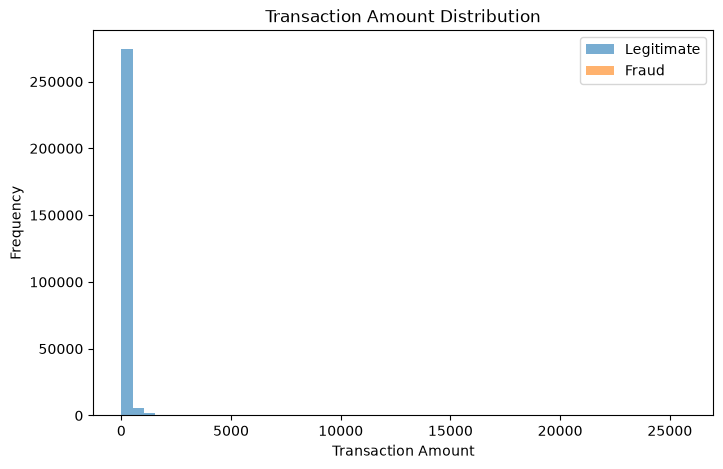

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(
    df_clean[df_clean["Class"] == 0]["Amount"],
    bins=50,
    alpha=0.6,
    label="Legitimate"
)

plt.hist(
    df_clean[df_clean["Class"] == 1]["Amount"],
    bins=50,
    alpha=0.6,
    label="Fraud"
)

plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")
plt.title("Transaction Amount Distribution")
plt.legend()

plt.show()

In [ ]:
df_clean.groupby("Class")["Amount"].agg(
    ["count", "mean", "median", "min", "max"]
)

,count,mean,median,min,max
Class,,,,,
0,283253,88.413575,22.00,0.0,25691.16
1,473,123.871860,9.82,0.0,2125.87


In [ ]:
class_counts = df_clean["Class"].value_counts()

print("Legitimate transactions:", class_counts[0])
print("Fraudulent transactions:", class_counts[1])

print("\nFraud percentage:")
print(df_clean["Class"].mean() * 100)

Legitimate transactions: 283253
Fraudulent transactions: 473

Fraud percentage:
0.1667101358352777


In [ ]:
df_clean = df.drop_duplicates().copy()

print("Original:", df.shape)
print("After removing duplicates:", df_clean.shape)

Original: (284807, 31)
After removing duplicates: (283726, 31)


In [ ]:
df_clean.groupby("Class")["Amount"].agg(
    ["count", "mean", "median", "min", "max"]
)

,count,mean,median,min,max
Class,,,,,
0,283253,88.413575,22.00,0.0,25691.16
1,473,123.871860,9.82,0.0,2125.87


In [ ]:
print(df.dtypes.value_counts())

float64    30
int64       1
Name: count, dtype: int64


In [ ]:
print("Missing values:", df.isnull().sum().sum())

Missing values: 0


In [ ]:
# Compare duplicate counts by class

print("All transactions:")
print(df["Class"].value_counts())

print("\nDuplicate rows:")
print(df[df.duplicated()]["Class"].value_counts())

All transactions:
Class
0    284315
1       492
Name: count, dtype: int64

Duplicate rows:
Class
0    1062
1      19
Name: count, dtype: int64


In [ ]:
# Check the class distribution of duplicated rows

duplicate_rows = df[df.duplicated(keep=False)]

print("Total rows involved in duplicates:", len(duplicate_rows))

print("\nClass distribution among duplicate rows:")
print(duplicate_rows["Class"].value_counts())

print("\nPercentage:")
print(
    duplicate_rows["Class"]
    .value_counts(normalize=True)
    .mul(100)
    .round(4)
)

Total rows involved in duplicates: 1854

Class distribution among duplicate rows:
Class
0    1822
1      32
Name: count, dtype: int64

Percentage:
Class
0    98.274
1     1.726
Name: proportion, dtype: float64


In [ ]:
# Check duplicate rows
duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 1081


In [ ]:
# Check missing values
missing_values = df.isnull().sum()

print("Columns with missing values:")
print(missing_values[missing_values > 0])

print("\nTotal missing values:", df.isnull().sum().sum())

Columns with missing values:
Series([], dtype: int64)

Total missing values: 0


In [ ]:
print("\nFirst 5 rows:")
print(df.head().to_string())

print("\nFraud distribution:")
print(df["Class"].value_counts())


First 5 rows:
   Time        V1        V2        V3        V4        V5        V6        V7        V8        V9       V10       V11       V12       V13       V14       V15       V16       V17       V18       V19       V20       V21       V22       V23       V24       V25       V26       V27       V28  Amount  Class
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599  0.098698  0.363787  0.090794 -0.551600 -0.617801 -0.991390 -0.311169  1.468177 -0.470401  0.207971  0.025791  0.403993  0.251412 -0.018307  0.277838 -0.110474  0.066928  0.128539 -0.189115  0.133558 -0.021053  149.62      0
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803  0.085102 -0.255425 -0.166974  1.612727  1.065235  0.489095 -0.143772  0.635558  0.463917 -0.114805 -0.183361 -0.145783 -0.069083 -0.225775 -0.638672  0.101288 -0.339846  0.167170  0.125895 -0.008983  0.014724    2.69      0
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.79146

In [ ]:
import pandas as pd
import os

# Load the actual dataset
df = pd.read_csv("../data/creditcard.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Dataset loaded successfully!
Shape: (284807, 31)

Columns:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


In [ ]:
print(df["Class"].value_counts())

Class
0    284315
1       492
Name: count, dtype: int64


In [ ]:
df = pd.read_csv("../data/creditcard.csv")

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

Shape: (284807, 31)
Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


In [ ]:
import pandas as pd
import os

print(os.listdir("../data"))

['creditcard.csv', 'creditcard_tmp.csv']


In [ ]:
df = pd.read_csv("../data/creditcard.csv")

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

Shape: (284807, 31)
Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


In [ ]:
import pandas as pd
import os

print(os.listdir("../data"))

['creditcard.csv', 'creditcard_tmp.csv']


In [ ]:
print(df.shape)
print(df.columns.tolist())
print(df.head(10).to_string())

(284807, 31)
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']
   Time        V1        V2        V3        V4        V5        V6        V7        V8        V9       V10       V11       V12       V13       V14       V15       V16       V17       V18       V19       V20       V21       V22       V23       V24       V25       V26       V27       V28  Amount  Class
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599  0.098698  0.363787  0.090794 -0.551600 -0.617801 -0.991390 -0.311169  1.468177 -0.470401  0.207971  0.025791  0.403993  0.251412 -0.018307  0.277838 -0.110474  0.066928  0.128539 -0.189115  0.133558 -0.021053  149.62      0
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803  0.085102 -0.255425 -0.166974  1.612727  1.065235  0.489095 -0.143772  0.635558  0.46391

In [ ]:
import pandas as pd

path = "../data/creditcard.csv"

print("File exists:", os.path.exists(path))
print("File size:", os.path.getsize(path), "bytes")

df = pd.read_csv(path)

print("\nShape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst rows:")
print(df.head(10).to_string())

File exists: True
File size: 150828752 bytes

Shape: (284807, 31)

Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

First rows:
   Time        V1        V2        V3        V4        V5        V6        V7        V8        V9       V10       V11       V12       V13       V14       V15       V16       V17       V18       V19       V20       V21       V22       V23       V24       V25       V26       V27       V28  Amount  Class
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599  0.098698  0.363787  0.090794 -0.551600 -0.617801 -0.991390 -0.311169  1.468177 -0.470401  0.207971  0.025791  0.403993  0.251412 -0.018307  0.277838 -0.110474  0.066928  0.128539 -0.189115  0.133558 -0.021053  149.62      0
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803  0.085102 -0

In [ ]:
import os

print("Current notebook directory:")
print(os.getcwd())

print("\nFiles in data folder:")
print(os.listdir("../data"))

Current notebook directory:
c:\Users\Lenovo\Desktop\IBM-Z-Fraud-Detection\notebooks

Files in data folder:
['creditcard.csv', 'creditcard_tmp.csv']


In [ ]:
print(df.head().to_string())

   Time        V1        V2        V3        V4        V5        V6        V7        V8        V9       V10       V11       V12       V13       V14       V15       V16       V17       V18       V19       V20       V21       V22       V23       V24       V25       V26       V27       V28  Amount  Class
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599  0.098698  0.363787  0.090794 -0.551600 -0.617801 -0.991390 -0.311169  1.468177 -0.470401  0.207971  0.025791  0.403993  0.251412 -0.018307  0.277838 -0.110474  0.066928  0.128539 -0.189115  0.133558 -0.021053  149.62      0
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803  0.085102 -0.255425 -0.166974  1.612727  1.065235  0.489095 -0.143772  0.635558  0.463917 -0.114805 -0.183361 -0.145783 -0.069083 -0.225775 -0.638672  0.101288 -0.339846  0.167170  0.125895 -0.008983  0.014724    2.69      0
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461  0.247676 -1.

In [ ]:
df.shape


(284807, 31)

In [ ]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
df = pd.read_csv("../data/creditcard.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [ ]:
import pandas as pd
import numpy as np

print("Environment working!")

Environment working!
